# Hands‑On Data Cleaning Notebook

*Generated: 2025-11-06 11:15*

This notebook guides you through a rigorous cleaning pass for your **capstone dataset**. Fill the TODOs and run cells in order. Keep this under version control (commits with meaningful messages).

## 1. DataSet Configuration
- Make sure your csv file(s) are in `data/`.
- Update `dataset_path` below.
- Modify/Update configurations here to set the base

In [1]:
# Imports
# Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

dataset_path = "../data/homicides.csv"
dataset_maxrows = 200

df = pd.read_csv(dataset_path)
#df.options.max(dataset_maxrows)  -- example of configuration


print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5079 entries, 0 to 5078
Data columns (total 5 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Entity                               5079 non-null   object 
 1   Code                                 4421 non-null   object 
 2   Year                                 5079 non-null   int64  
 3   Homicides - sex: Total - age: Total  4887 non-null   float64
 4   World regions according to OWID      272 non-null    object 
dtypes: float64(1), int64(1), object(3)
memory usage: 198.5+ KB
None


## 2) DataSet Analysis 
- Updating existing column names from raw dataset for uniformity across datasets
- Performing head(), info() operations to get an overview of data
- Convert column types wherever needed
- Converting all string to small case for efficient data operations

In [2]:
df.columns = ["country_name","country_code","year","homicide_data","world_regions"]

df["country_name"] = df["country_name"].astype("string")
df["country_code"] = df["country_code"].astype("string")
df["world_regions"] = df["world_regions"].astype("string")


df["country_name"] = df["country_name"].str.lower()
df["country_code"] = df["country_code"].str.lower()
df["world_regions"] = df["world_regions"].str.lower()

df["homicide_data"] = df["homicide_data"].round(2)

#print(df.head())           #shows first 5 records with header
#print(df.info())            #gives information about the column names along with their datatypes
print(df)                   #shows first 5 and last 5 data from datasets



     country_name country_code  year  homicide_data world_regions
0     afghanistan          afg  2009         1115.0          <NA>
1     afghanistan          afg  2010          983.0          <NA>
2     afghanistan          afg  2011         1231.0          <NA>
3     afghanistan          afg  2012         1948.0          <NA>
4     afghanistan          afg  2015         3367.0          <NA>
...           ...          ...   ...            ...           ...
5074     zimbabwe          zwe  2019          790.0          <NA>
5075     zimbabwe          zwe  2020          780.0          <NA>
5076     zimbabwe          zwe  2021          982.0          <NA>
5077     zimbabwe          zwe  2022         1086.0          <NA>
5078     zimbabwe          zwe  2023            NaN        africa

[5079 rows x 5 columns]


## 3) Missing Data: Identify → Decide → Apply
- Find empty records

In [3]:
# Identify missing data

missing_counts = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing_counts / len(df) * 100).round(2)
missing_report = pd.DataFrame({"missing_count": missing_counts, "missing_pct": missing_pct})
print(missing_report)

# show the missing rows

bool_series = pd.isnull(df["country_code"])
missing_country_code_data = df[bool_series]
#print(missing_country_code_data)

unique_countries = df['country_name'].unique()
unique_country_code = df['country_code'].unique()

#print(unique_countries)
#print(unique_country_code)

print(missing_country_code_data)
print(missing_country_code_data["country_name"].unique())



               missing_count  missing_pct
world_regions           4807        94.64
country_code             658        12.96
homicide_data            192         3.78
country_name               0         0.00
year                       0         0.00
             country_name country_code  year  homicide_data world_regions
12            africa (un)         <NA>  2000      113808.16          <NA>
13            africa (un)         <NA>  2001      116305.69          <NA>
14            africa (un)         <NA>  2002      118711.86          <NA>
15            africa (un)         <NA>  2003      117923.05          <NA>
16            africa (un)         <NA>  2004      118696.56          <NA>
...                   ...          ...   ...            ...           ...
5003  western europe (un)         <NA>  2019        1776.00          <NA>
5004  western europe (un)         <NA>  2020        1860.00          <NA>
5005  western europe (un)         <NA>  2021        1793.00          <NA>
5006  we

## 4) Remove inconsitent data
- remove data that has empty country code

In [4]:
df = df.dropna(subset=["country_code"])
df = df.drop(df[df['country_name'] == 'world'].index)

print(df)


missing_counts_1 = df.isnull().sum().sort_values(ascending=False)
missing_pct_1 = (missing_counts_1 / len(df) * 100).round(2)
missing_report_1 = pd.DataFrame({"missing_count": missing_counts_1, "missing_pct": missing_pct_1})
print(missing_report_1)

unique_countries_1 = df['country_name'].unique()
unique_country_code_1 = df['country_code'].unique()


#missing_homicide_data = df[df['homicide_data'].isna()]
#print(missing_homicide_data.to_string())
#print(unique_countries_1)
#print(unique_country_code_1)



     country_name country_code  year  homicide_data world_regions
0     afghanistan          afg  2009         1115.0          <NA>
1     afghanistan          afg  2010          983.0          <NA>
2     afghanistan          afg  2011         1231.0          <NA>
3     afghanistan          afg  2012         1948.0          <NA>
4     afghanistan          afg  2015         3367.0          <NA>
...           ...          ...   ...            ...           ...
5074     zimbabwe          zwe  2019          790.0          <NA>
5075     zimbabwe          zwe  2020          780.0          <NA>
5076     zimbabwe          zwe  2021          982.0          <NA>
5077     zimbabwe          zwe  2022         1086.0          <NA>
5078     zimbabwe          zwe  2023            NaN        africa

[4397 rows x 5 columns]
               missing_count  missing_pct
world_regions           4140        94.16
homicide_data            177         4.03
country_name               0         0.00
year           

## 5) Remove Duplicate Records

In [5]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows found:", duplicate_count)

if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicates removed. New shape:", df.shape)
else:
    print("No duplicate rows detected.")

Duplicate rows found: 0
No duplicate rows detected.


## 6) Detect Outliers with Visualizations

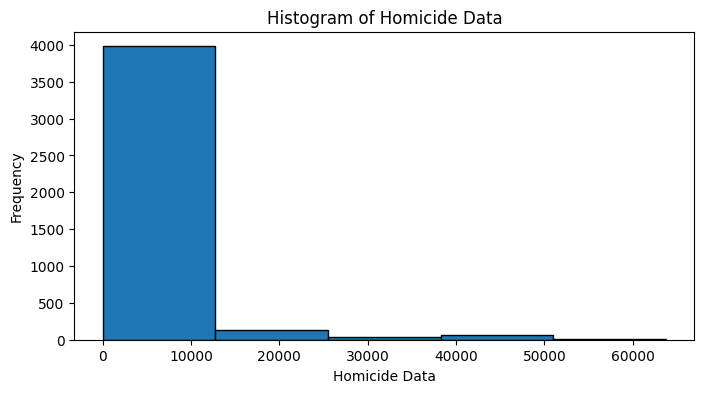

In [6]:
# HISTOGRAMS (one plot per numeric column)

plt.figure(figsize=(8, 4))
plt.hist(df["homicide_data"], bins=5, edgecolor="black")
plt.title("Histogram of Homicide Data")
plt.xlabel("Homicide Data")
plt.ylabel("Frequency")
plt.show()



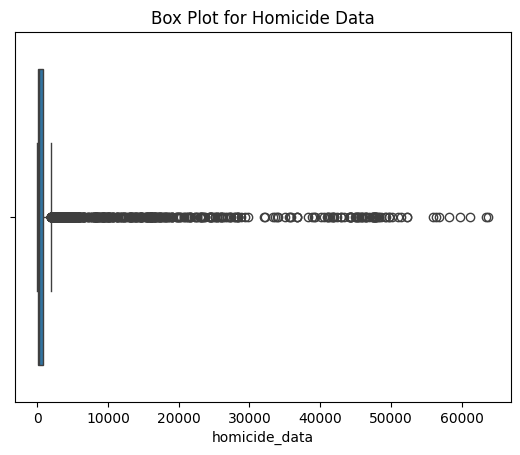

In [7]:
# BOX PLOTS (one plot per numeric column)
sns.boxplot(x=df['homicide_data'])
plt.title("Box Plot for Homicide Data")
plt.show()


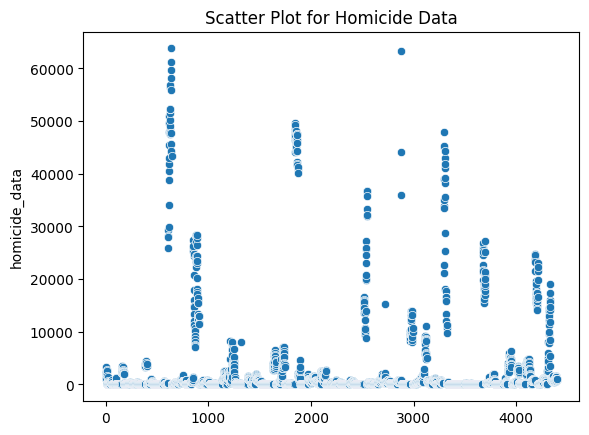

In [8]:
# Scatter Plot
sns.scatterplot(x=range(len(df['homicide_data'])), y=df['homicide_data'])
plt.title("Scatter Plot for Homicide Data")
plt.show()

In [9]:

# Calculate Q1, Q3, and IQR
Q1 = df["homicide_data"].quantile(0.25)
Q3 = df["homicide_data"].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Detect outliers
outliers = df[(df["homicide_data"] < lower_bound) | (df["homicide_data"] > upper_bound)]

print("Outliers:")
print(outliers)

Outliers:
     country_name country_code  year  homicide_data world_regions
3     afghanistan          afg  2012         1948.0          <NA>
4     afghanistan          afg  2015         3367.0          <NA>
5     afghanistan          afg  2016         2318.0          <NA>
6     afghanistan          afg  2017         2424.0          <NA>
7     afghanistan          afg  2018         2474.0          <NA>
...           ...          ...   ...            ...           ...
4940    venezuela          ven  2017        14665.0          <NA>
4941    venezuela          ven  2019        11874.0          <NA>
4942    venezuela          ven  2020         8384.0          <NA>
4943    venezuela          ven  2021         5444.0          <NA>
4944    venezuela          ven  2022         3568.0          <NA>

[644 rows x 5 columns]


In [10]:
# Compute z-scores
df["zscore"] = (df["homicide_data"] - df["homicide_data"].mean()) / df["homicide_data"].std()

# Mark values beyond ±3 standard deviations
outliers_z = df[df["zscore"].abs() > 3]

print("Outliers (Z-score):")
print(outliers_z)

Outliers (Z-score):
       country_name country_code  year  homicide_data world_regions    zscore
703          brazil          bra  1990       29301.19          <NA>  3.651045
704          brazil          bra  1991       28148.47          <NA>  3.495118
705          brazil          bra  1992       25966.84          <NA>  3.200010
706          brazil          bra  1993       28012.75          <NA>  3.476759
707          brazil          bra  1994       29851.41          <NA>  3.725473
...             ...          ...   ...            ...           ...       ...
4189   south africa          zaf  1998       25127.00          <NA>  3.086406
4212   south africa          zaf  2021       25181.00          <NA>  3.093710
4213   south africa          zaf  2022       27272.00          <NA>  3.376558
4793  united states          usa  1991       24703.00          <NA>  3.029051
4795  united states          usa  1993       24526.00          <NA>  3.005109

[117 rows x 6 columns]


## 7) Save Outputs

In [11]:
# Save cleaned dataset (CSV). Keep raw file untouched.
clean_path = "../data/homicide_data_clean.csv"  # TODO: update name
df.to_csv(clean_path, index=False)
print("Saved cleaned file to:", clean_path)

# Optional: Save a small data dictionary (columns and inferred types)
data_dict = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str),
    "non_null": df.notnull().sum(),
    "unique": df.nunique()
})
data_dict_path = "../data/homicide_data_dictionary.csv"
data_dict.to_csv(data_dict_path, index=False)
print("Saved data dictionary to:", data_dict_path)


Saved cleaned file to: ../data/homicide_data_clean.csv
Saved data dictionary to: ../data/homicide_data_dictionary.csv
